In [17]:
import torch
import torch.distributions as dist
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import math
import json
import models as m
import shutil

#### CONFIG Sauvegarde

In [18]:
SAVE = True  

def get_next_run_id(exp_dir: str) -> str:
    existing = [
        d for d in os.listdir(exp_dir)
        if d.isdigit() and len(d) == 3
    ] 
    if not existing:
        return "001"
    return f"{int(max(existing))+1:03d}"

BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")
os.makedirs(RUNS_ROOT, exist_ok=True)

EXP_NAME = "gmm_baseline"
EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

RUN_ID = get_next_run_id(EXP_DIR)
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)
print("RUN_ID:", RUN_ID)

if SAVE:
    os.makedirs(RUN_DIR, exist_ok=True)
    FIG_DIR = os.path.join(RUN_DIR, "figures")
    WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
    LOGS_DIR = os.path.join(RUN_DIR, "logs")
    VIDEO_DIR = os.path.join(RUN_DIR, "videos")
    OUTDIR = os.path.join(VIDEO_DIR, "out/")
    os.makedirs(FIG_DIR, exist_ok=True)
    os.makedirs(WEIGHTS_DIR, exist_ok=True)
    os.makedirs(LOGS_DIR, exist_ok=True)
    os.makedirs(VIDEO_DIR, exist_ok=True)
else:
    FIG_DIR = WEIGHTS_DIR = LOGS_DIR = VIDEO_DIR = None

RUN_ID: 004


#### Device

In [19]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available(): 
    device = torch.device('cuda:0')
elif torch.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype()).to(device)

print("Device:", device)

Device: mps


#### GMM Dataset

In [20]:
mean = torch.stack(
    [
        t([-4, 4]),
        t([4, -4]),
        t([0, 0]),
    ],
    dim=0
).to(device)

cov = torch.stack(
    [
        torch.eye(2, device=device) / 10.0,
        torch.eye(2, device=device),
        torch.eye(2, device=device) / 40.0,
    ],
    dim=0
).to(device)

weights = dist.Categorical(t([0.1, 0.6, 0.3]))
gaussians = dist.MultivariateNormal(mean, cov)
dataset = dist.MixtureSameFamily(weights, gaussians)

#### Loss + utils

In [21]:
def construct_noise_linspace(min_val, max_val, L):
    return torch.linspace(min_val, max_val, L).flip(0).to(device)

def construct_noise_logspace(sigma_min, sigma_max, L):
    return torch.logspace(
        torch.log10(t(sigma_min)),
        torch.log10(t(sigma_max)), L
    ).flip(0).to(device)

def LossNCSN(model, x, sigmas, return_per_sigma=False):
    """
    Version 2D, même logique que CelebA mais sans EPS_TRAINNING.
    x: (B, 2)
    sigmas: (N_SIGMAS,)
    """
    B = x.size(0)
    n_sigmas = len(sigmas)

    idx = torch.randint(0, n_sigmas, (B,), device=x.device)
    sigma_vals = sigmas[idx]                     # (B,)

    eps = torch.randn_like(x)                    # (B,2)
    sigma_expand = sigma_vals.view(B, 1)         # (B,1)
    x_noisy = x + sigma_expand * eps

    s_hat = model(x_noisy, sigma_vals.view(B, 1))  # (B,2)
    target = -eps / (sigma_expand + 1e-8)          # (B,2)

    residual = (s_hat - target)**2                # (B,2)
    loss_per_sample = residual.sum(dim=1) * (sigma_vals**2)  # (B,)
    loss = loss_per_sample.mean()

    if not return_per_sigma:
        return loss

    # stats par sigma
    loss_sum = torch.zeros(n_sigmas, device=x.device)
    count_sum = torch.zeros(n_sigmas, device=x.device)

    loss_sum.index_add_(0, idx, loss_per_sample.detach())
    count_sum.index_add_(0, idx, torch.ones_like(loss_per_sample))

    return loss, loss_sum.cpu(), count_sum.cpu()

#### Training config

In [22]:
batch_size  = 4 * 128
N_train     = 40000
EVAL_EVERY  = 1000
lr          = 1e-4

HIDDEN_DIM    = 128
SIGMA_EMB_DIM = 64

SIGMA_MIN      = 1e-1
SIGMA_MAX      = 10.0
N_SIGMAS       = 10
SIGMA_SCHEDULE = "log"

if SIGMA_SCHEDULE == "log":
    sigmas = construct_noise_logspace(SIGMA_MIN, SIGMA_MAX, N_SIGMAS)
else:
    sigmas = construct_noise_linspace(SIGMA_MIN, SIGMA_MAX, N_SIGMAS)

x_dim = 2

# Sauvegarde aussi le dataset (mean, cov, weights) pour la recréation en eval
if SAVE:
    hparams = {
        "batch_size": batch_size,
        "N_train": N_train,
        "EVAL_EVERY": EVAL_EVERY,
        "lr": lr,
        "sigma": {
            "schedule": SIGMA_SCHEDULE,
            "min": SIGMA_MIN,
            "max": SIGMA_MAX,
            "n_sigmas": N_SIGMAS,
            "values": [float(s) for s in sigmas],
        },
        "device": str(device),
        "model": {
            "x_dim": x_dim,
            "hidden_dim": HIDDEN_DIM,
            "sigma_emb_dim": SIGMA_EMB_DIM,
        },
        "dataset": {
            "mean": mean.detach().cpu().tolist(),          # (K,2)
            "cov": cov.detach().cpu().tolist(),            # (K,2,2)
            "weights": weights.probs.detach().cpu().tolist(),  # (K,)
        },
    }
    with open(os.path.join(LOGS_DIR, "hparams.json"), "w") as f:
        json.dump(hparams, f, indent=4)

#### Training loop

In [23]:
model = m.ScoreNetworkConditionned1(
    x_dim=x_dim,              # ici x_dim = 2 pour ton GMM
    hidden_dim=HIDDEN_DIM,
    sigma_emb_dim=SIGMA_EMB_DIM
).to(device)

# Comptage du nombre de paramètres
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n_params = count_parameters(model)
print(model)
print(f"\nNombre de paramètres trainables : {n_params} "
      f"(≈ {n_params/1e3:.1f}k)")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

L = []
eval_steps = []
L_sigma_history = []

loss_sigma_running  = torch.zeros(N_SIGMAS)
count_sigma_running = torch.zeros(N_SIGMAS)

for step in range(N_train):
    x = dataset.sample((batch_size,)).to(device)

    optimizer.zero_grad()
    loss, loss_sigma_sum, count_sigma_sum = LossNCSN(
        model, x, sigmas, return_per_sigma=True
    )
    loss.backward()
    optimizer.step()

    L.append(loss.item())
    loss_sigma_running  += loss_sigma_sum
    count_sigma_running += count_sigma_sum

    if (step + 1) % EVAL_EVERY == 0 or step == N_train - 1:
        model.eval()
        eval_steps.append(step + 1)

        print(f"[{step+1}/{N_train}] Loss (last {EVAL_EVERY}) = {np.mean(L[-EVAL_EVERY:]):.4f}")

        mean_sigma = (loss_sigma_running /
                      (count_sigma_running + 1e-8)).numpy()
        L_sigma_history.append(mean_sigma)

        loss_sigma_running.zero_()
        count_sigma_running.zero_()

        if SAVE:
            torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "model.pt"))
            np.save(os.path.join(LOGS_DIR, "train_loss.npy"), np.array(L))
            np.save(os.path.join(LOGS_DIR, "steps_eval.npy"), np.array(eval_steps))
            np.save(os.path.join(LOGS_DIR, "train_loss_per_sigma.npy"),
                    np.array(L_sigma_history))
            np.save(os.path.join(LOGS_DIR, "sigmas.npy"),
                    sigmas.detach().cpu().numpy())

        model.train()

# sauvegarde finale
if SAVE:
    np.save(os.path.join(LOGS_DIR, "train_loss.npy"), np.array(L))
    np.save(os.path.join(LOGS_DIR, "steps_eval.npy"), np.array(eval_steps))
    np.save(os.path.join(LOGS_DIR, "train_loss_per_sigma.npy"),
            np.array(L_sigma_history))
    np.save(os.path.join(LOGS_DIR, "sigmas.npy"),
            sigmas.detach().cpu().numpy())
    torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "model.pt"))

ScoreNetworkConditionned1(
  (sigma_embedding): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
  )
  (in_proj): Linear(in_features=66, out_features=128, bias=True)
  (block1): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (block2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (out_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (out_proj): Linear(in_features=128, out_features=2, bias=True)
)

Nombre de paramètres trainables : 79938 (≈ 79.9k)
[1000/40000] Loss (last 1000) = 1.3459
[2000/40000] Loss (last 1000) = 1.1380
[3000/

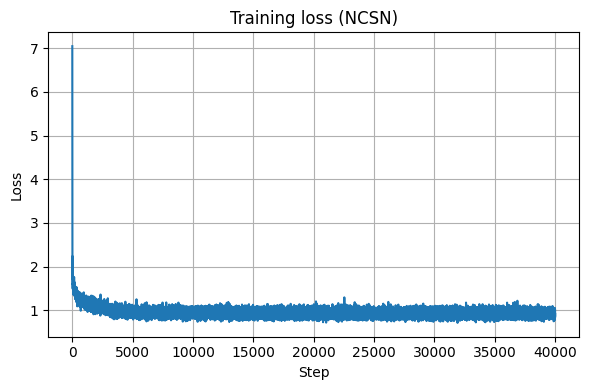

In [24]:
plt.figure(figsize=(6,4))
plt.title("Training loss (NCSN)")
plt.plot(L)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
if SAVE:
    plt.savefig(os.path.join(FIG_DIR, "train_loss.png"), dpi=200)
plt.show()